In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = pd.read_csv("dataset.csv")
features = data.iloc[:, :-1]
labels = data.iloc[:, -1]



In [3]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(features, encoded_labels,test_size=0.2, random_state=42)

print("Classes: ", label_encoder.classes_)

Classes:  ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       894
           B       1.00      1.00      1.00       880
           C       1.00      1.00      1.00       765
           D       1.00      1.00      1.00       968
           E       1.00      1.00      1.00       912
           F       1.00      1.00      1.00      1096
           G       1.00      1.00      1.00       955
           H       1.00      1.00      1.00       933
           I       1.00      1.00      1.00       947
           J       1.00      1.00      1.00      1031
           K       1.00      1.00      1.00      1019
           L       1.00      1.00      1.00      1036
           M       0.98      0.99      0.98       583
           N       0.99      0.98      0.98       460
           O       1.00      1.00      1.00       913
           P       1.00      0.99      1.00       790
           Q       1.00      1.00      1.00       812
    

In [7]:
import joblib
joblib.dump(rf_model, 'recognizer_model.pkl')
print("Model saved")

Model saved


In [8]:
joblib.dump(label_encoder, 'label_encoder_model.pkl')

['label_encoder_model.pkl']

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


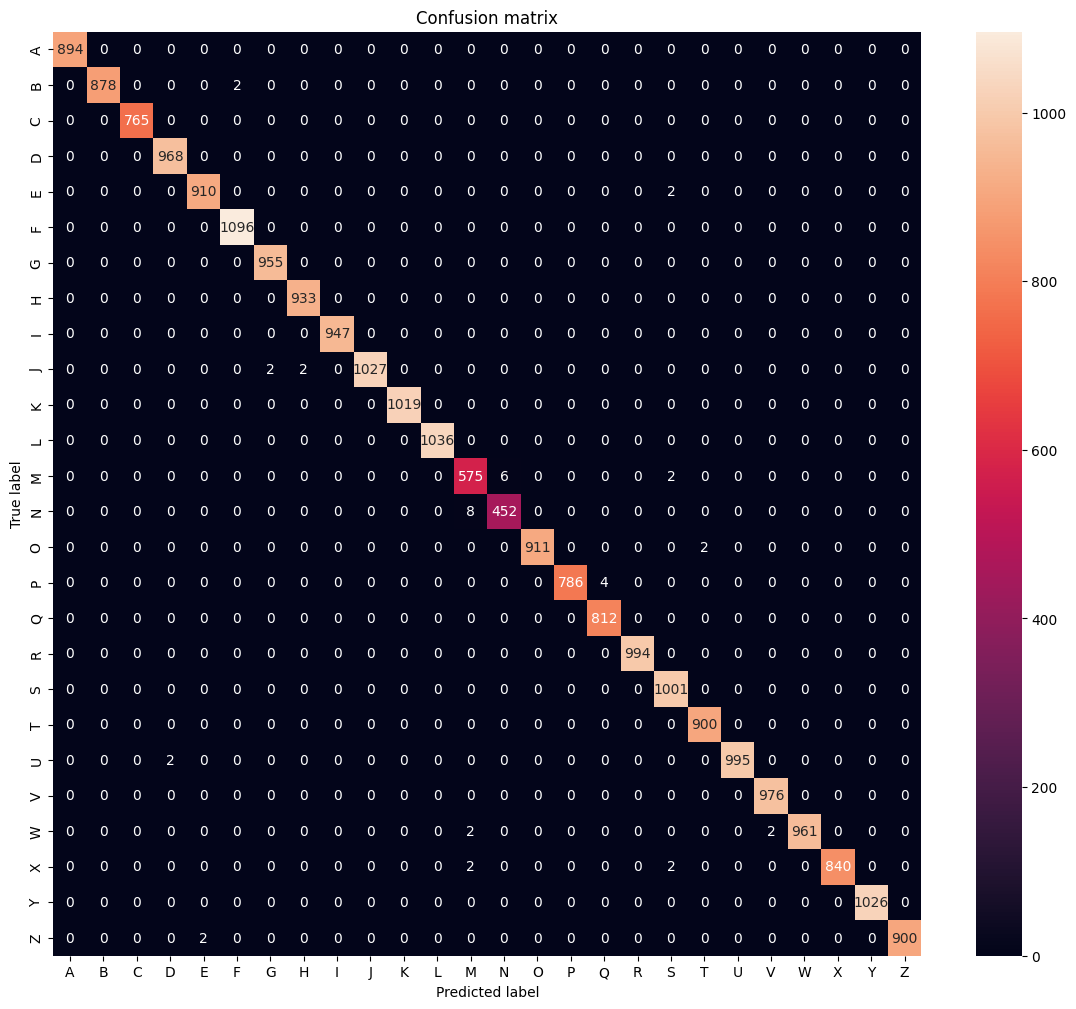

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()